# Double Heston calibration repair

This notebook displays completed results. It does not retrain or tune on assessment data. Read RESULTS.md for limits and gate counts.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown
BASE = Path.cwd()
if not (BASE / 'RESULTS.md').exists():
    BASE = BASE / 'outputs' / 'calibration_repair'
assert (BASE / 'RESULTS.md').exists(), 'Open from repository root or this notebook folder.'
display(Markdown((BASE / 'RESULTS.md').read_text().split('## Figures')[0]))


# Double Heston calibration repair: measured results

The repair improves development calibration. Perfect recovery of all ten parameters is not established across the complete assessment.

## Training and real-data development validation

Three independent fine-tunes used the same base checkpoint and a 600-step budget. Selection used development validation only, before the independent synthetic assessment. Seed 43, step 500 is the selected primary.

| Model | Selected step | Selection price/vega RMSE | Actual IV RMSE, precision checked | Unresolved IV quotes |
|---|---:|---:|---:|---:|
| Base | base | 0.0301763 | 0.0356952 | 0 |
| Seed 17 | 400 | 0.0235277 | 0.035119 | 0 |
| Seed 29 | 300 | 0.0238325 | 0.0350224 | 0 |
| Seed 43 | 500 | 0.0234392 | 0.035267 | 0 |

All 203 validation surfaces and all 1,607 quote holds are included per model. These are development results, not forward prediction or a new unexamined market test. Prices are normalised undiscounted calls; IV uses fractional annual volatility (0.01 is one volatility point).

The selected primary improves actual pooled IV RMSE by about 1.20%, not the roughly 22% improvement in the selection price/vega approximation. Nine symbols improve; JSWENERGY and NIFTY worsen (NIFTY: 0.048854 → 0.050243). The approximation cannot be substituted for actual IV accuracy, and this is not evidence of universal improvement. Seed 29 has a lower actual IV RMSE here, but the prespecified selection remains seed 43.

The original 128-node evaluator returned three tiny negative call prices (one per repaired model), making each original all-quote IV metric unavailable. A uniform time-value threshold of 1e-10, applied to every model, triggered independent Carr–Madan inversion at 40 and 60 decimal precision for seven quotes, including the base model. All seven passed precision and tail checks. Original prices and failures are preserved in market_validation; numerical re-evaluation is in market_precision_checked. No observed quote, fitted parameter, checkpoint selection or assessment gate was changed. This numerical guard was introduced after tracing the failures, not claimed as preregistered.

## Independent synthetic recovery

24 independent parameter sets (seeds 905101/905102/905103), each evaluated with six expiries and one expiry, clean and 1% noisy: 96 conditions. All three repaired networks and the base network were assessed; exact-optimiser polish was applied only to the primary selected before the assessment. Every third strike was withheld. Calibration code receives no true parameters or quote holds.

| Primary arm | Geometry | Noise | Price target passed | All-parameter target passed | Both passed | Pooled price RMSE / spot |
|---|---|---:|---:|---:|---:|---:|
| Network only | rich | 0% | 0/24 | 0/24 | 0/24 | 0.00388554 |
| Network only | rich | 1% | 0/24 | 0/24 | 0/24 | 0.00292863 |
| Network only | single_expiry | 0% | 0/24 | 0/24 | 0/24 | 0.00175207 |
| Network only | single_expiry | 1% | 0/24 | 0/24 | 0/24 | 0.00122555 |
| Network + exact optimisation | rich | 0% | 23/24 | 21/24 | 21/24 | 3.40275e-06 |
| Network + exact optimisation | rich | 1% | 0/24 | 0/24 | 0/24 | 0.000498512 |
| Network + exact optimisation | single_expiry | 0% | 24/24 | 0/24 | 0/24 | 1.29208e-08 |
| Network + exact optimisation | single_expiry | 1% | 0/24 | 0/24 | 0/24 | 0.000552503 |
| Network + 3 refinement steps | rich | 0% | 0/24 | 0/24 | 0/24 | 0.000770665 |
| Network + 3 refinement steps | rich | 1% | 0/24 | 0/24 | 0/24 | 0.000545463 |
| Network + 3 refinement steps | single_expiry | 0% | 1/24 | 0/24 | 0/24 | 0.000328714 |
| Network + 3 refinement steps | single_expiry | 1% | 0/24 | 0/24 | 0/24 | 0.000460844 |

Price target: heldout RMSE ≤1e-6 of spot, convergent 96/128-node prices within 1e-6, no bound violations. Parameter target: every latent coordinate within 0.01 training standard deviations of its generating value. These thresholds were fixed in the protocol. They were not loosened after seeing results.

The synthetic richness ladder is 30/60/90/180/365/730 days with 15 strikes from 0.8 to 1.2 of spot. This is a controlled synthetic design, not a claim that all such maturities are available for Indian stock contracts. For the noisy runs, strict clean-recovery gates are diagnostic stress targets, not realistic guarantees of exact recovery from noisy observations.

A low price error with a failed parameter target is a failure of parameter recovery. Optimiser success flags are recorded separately in polish_runs.json; a budget-exhausted fit remains identifiable as such. The exact optimiser is part of the hybrid's reported runtime. It is not credited to the network alone.

Selected optimiser termination was successful in 60/96 hybrid conditions. Two noisy-rich hybrid fits have unresolved quadrature: 905103_00 (96/128-node difference 1.72e-4) and 905103_07 (7.77e-5). Both fail the price gate. Their finite 128-node errors remain in the pooled table above, which must not be mistaken for numerically certified accuracy.

### All four networks, same three-step refinement

| Model | Rich clean RMSE / spot | Rich noisy | Single clean | Single noisy |
|---|---:|---:|---:|---:|
| unified_v6/unified | 0.000729562 | 0.000656796 | 0.000468091 | 0.000458656 |
| seed_17/repaired | 0.000704703 | 0.000537725 | 0.000332723 | 0.000455954 |
| seed_29/repaired | 0.000527809 | 0.000491541 | 0.000360142 | 0.000463251 |
| seed_43/repaired | 0.000770665 | 0.000545463 | 0.000328714 | 0.000460844 |

The primary checkpoint was chosen on real-data development validation, not this table. It does not beat the base in every synthetic condition: rich-clean and single-expiry noisy pricing regress slightly. These regressions are retained; no alternative seed was selected after inspecting them.

### Example parameters: first prespecified clean rich case 905101_00

| Parameter | Generating value | Network only | Three-step refined | Hybrid exact optimisation |
|---|---:|---:|---:|---:|
| kappa_slow | 0.451571 | 0.457317 | 0.434951 | 0.451571 |
| theta_slow | 0.0318711 | 0.0566667 | 0.0385472 | 0.0318711 |
| sigma_slow | 0.0366608 | 0.110051 | 0.0491568 | 0.0366608 |
| rho_slow | -0.390588 | -0.371491 | -0.230117 | -0.390588 |
| v0_slow | 0.0520946 | 0.0667802 | 0.0589961 | 0.0520946 |
| kappa_fast | 8.06647 | 6.92104 | 7.99263 | 8.06647 |
| theta_fast | 0.078126 | 0.055892 | 0.071061 | 0.078126 |
| sigma_fast | 0.419563 | 0.442933 | 0.429097 | 0.419563 |
| rho_fast | -0.223261 | -0.0435797 | -0.236698 | -0.223261 |
| v0_fast | 0.0893865 | 0.0713578 | 0.0824603 | 0.0893865 |

These are one synthetic case's values, not a universal or market parameter set. Every estimate and its generating label, including failed recovery cases, is in all_parameter_recovery.csv. Market estimates are in market_validation/surface_parameters_and_metrics.csv with no invented truth labels.

## Changes and verification

- Correct entropy-bearing negative ELBO replaced the unsupported variance-loss collapse argument. Analytic tests verify appropriate expansion and contraction.
- Refinement uses the declared quote scale and per-surface objective acceptance. Invalid quotes are rejected, not removed from losses.
- Nonfinite objectives cannot corrupt moving loss scales. Checkpoints retain seed, optimiser state, RNG state, metrics and provenance.
- Calendar embargo covers all symbols in the new corpus; quote holds are removed before encoder feature construction. NIFTY carry and validation weight/noise fits use calibration strikes.
- Local sensitivity uses SVD and reports weak directions; encoder uncertainty is explicitly distinguished from refined estimates.

The final scoped verification log is verification_final.txt: 46 tests passed, with 18 PyTorch deprecation warnings. This is the repair/unified test set, not a claim that every historical repository test was executed. Source hashes, all checkpoint selections, data exclusions and runtime versions are saved beside the results.

## What remains unresolved

Ten unique true market parameters cannot be verified from real quotes because no such labels are observed. Noisy/short-tenor surfaces can support very different parameters with similar prices. The neural parameter MAE remains substantial; the approximate Gaussian posterior does not fully describe curved or multimodal ambiguity. The new market split is embargoed, but prior human/test inspection and historical checkpoint exposure cannot be undone.

Fast/slow ordering removes factor-label swapping; it does not remove all compensating parameter combinations. IV derived from the same option prices changes the weighting of errors, but is not an independent observation that can by itself guarantee identification. Clean rich recovery succeeded for 21/24 hybrid cases, while all 24 clean single-expiry cases failed the parameter gate despite passing the price gate. Unregularised noisy polish can overfit: it worsens pooled single-expiry price error and yields much larger parameter errors. Do not deploy it indiscriminately for noisy market quotes.

Strict quote-level liquidity leaves 3–7 NIFTY validation expiries, correcting the earlier 10+ claim under aggregate liquidity. Exact market IV and first-order price/vega metrics differ; neither should be silently substituted for the other. No new p-value or market superiority claim is made.

No further model/hyperparameter selection was made from this assessment. A future improvement cycle must preserve these results as development evidence and reserve new data for assessment.

The next defensible steps are noise-aware regularisation of weak parameter directions, selecting future models with actual IV metrics when IV accuracy is the objective, and evaluating on new untouched dates/parameter draws. Adding price-derived IV as another target or increasing optimisation steps alone does not provide missing identifying information.



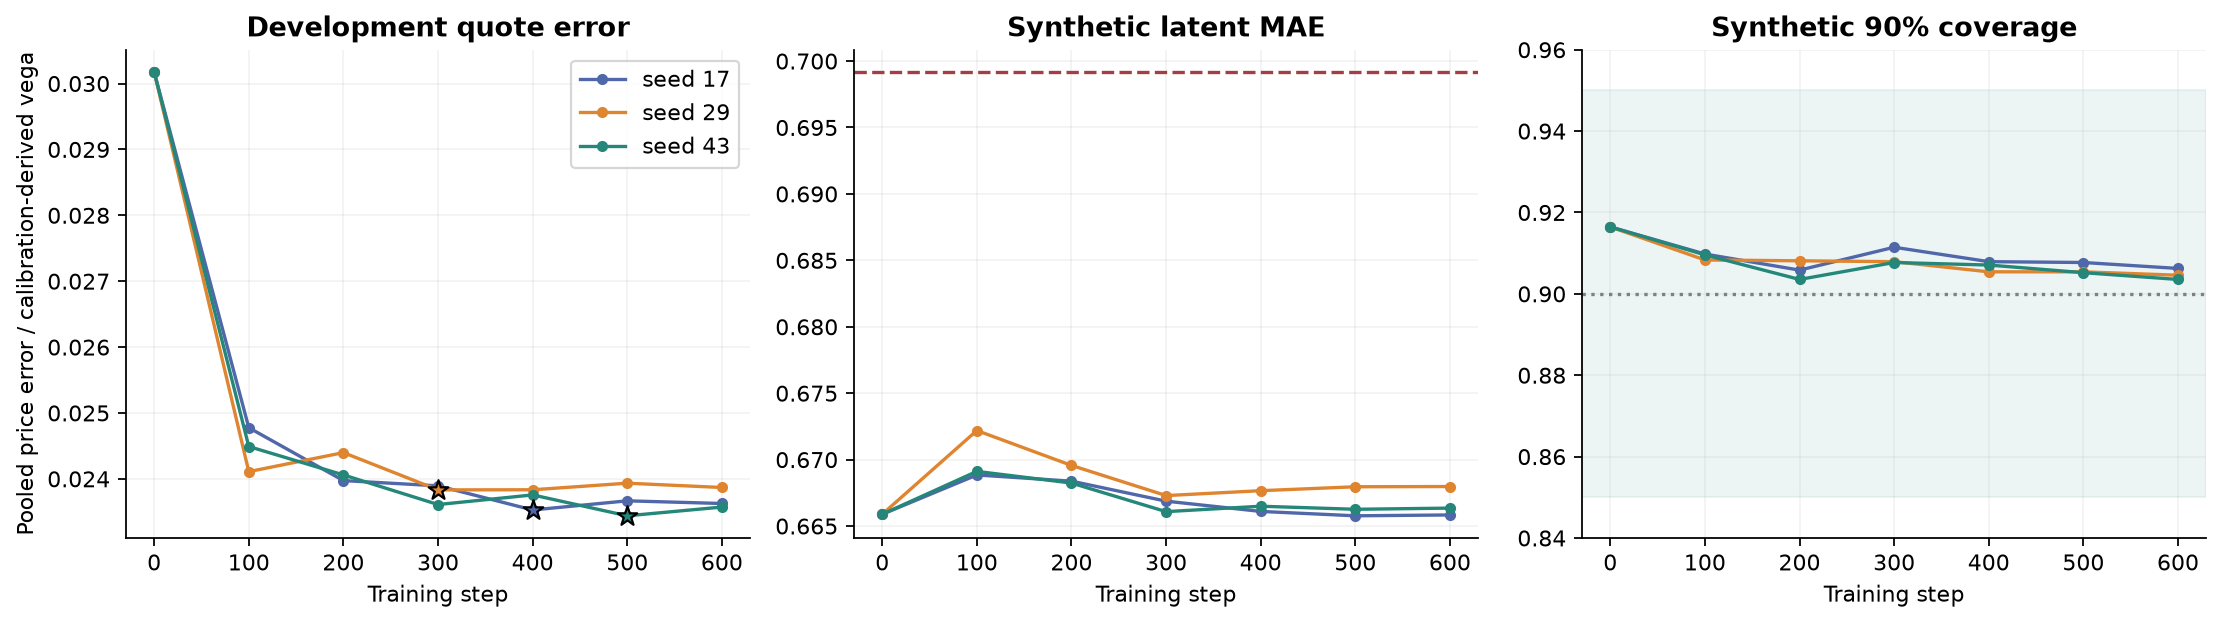

In [2]:
display(Image(filename=str(BASE / 'figures' / 'training_diagnostics.png')))


All three seeds improve the development quote metric. Synthetic recovery and marginal coverage remain near their starting levels; better pricing has not solved ten-parameter recovery. Stars mark validation-selected checkpoints.

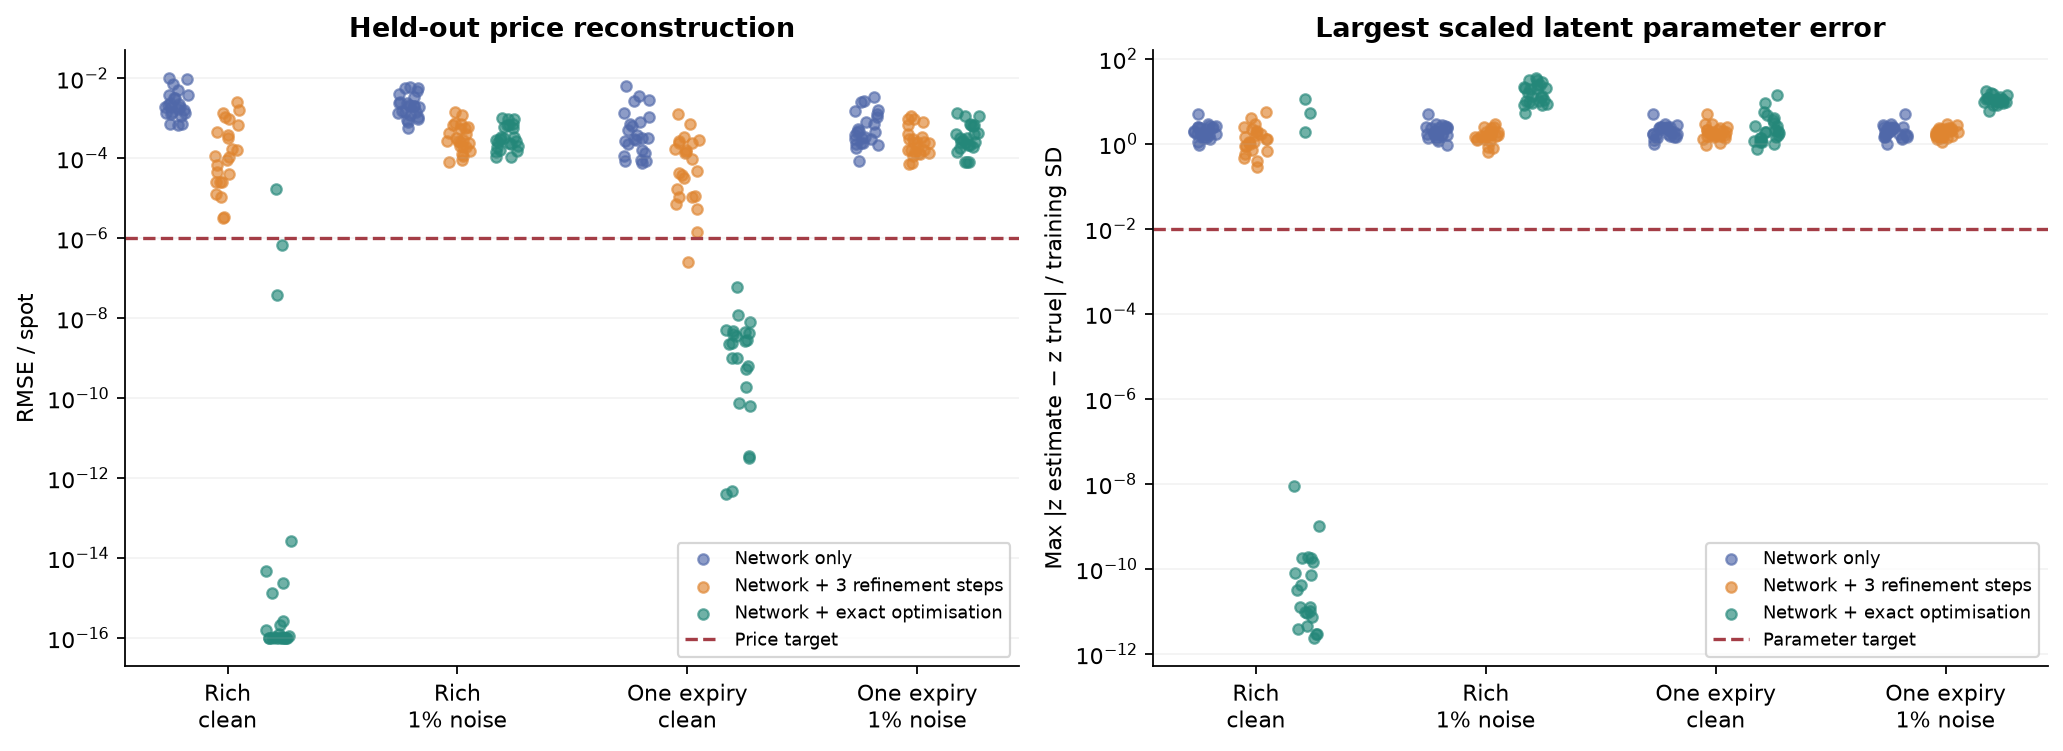

In [3]:
display(Image(filename=str(BASE / 'figures' / 'price_and_parameter_recovery.png')))


Each dot is a separate case (tiny horizontal offsets only separate markers). Low price error does not imply low parameter error. Clean multi-expiry surfaces give the strongest recovery evidence. Red lines are the fixed targets; plot values below 1e-16 use that display floor only. Two noisy-rich hybrid prices fail the quadrature check, so their displayed 128-node errors are numerically unresolved.

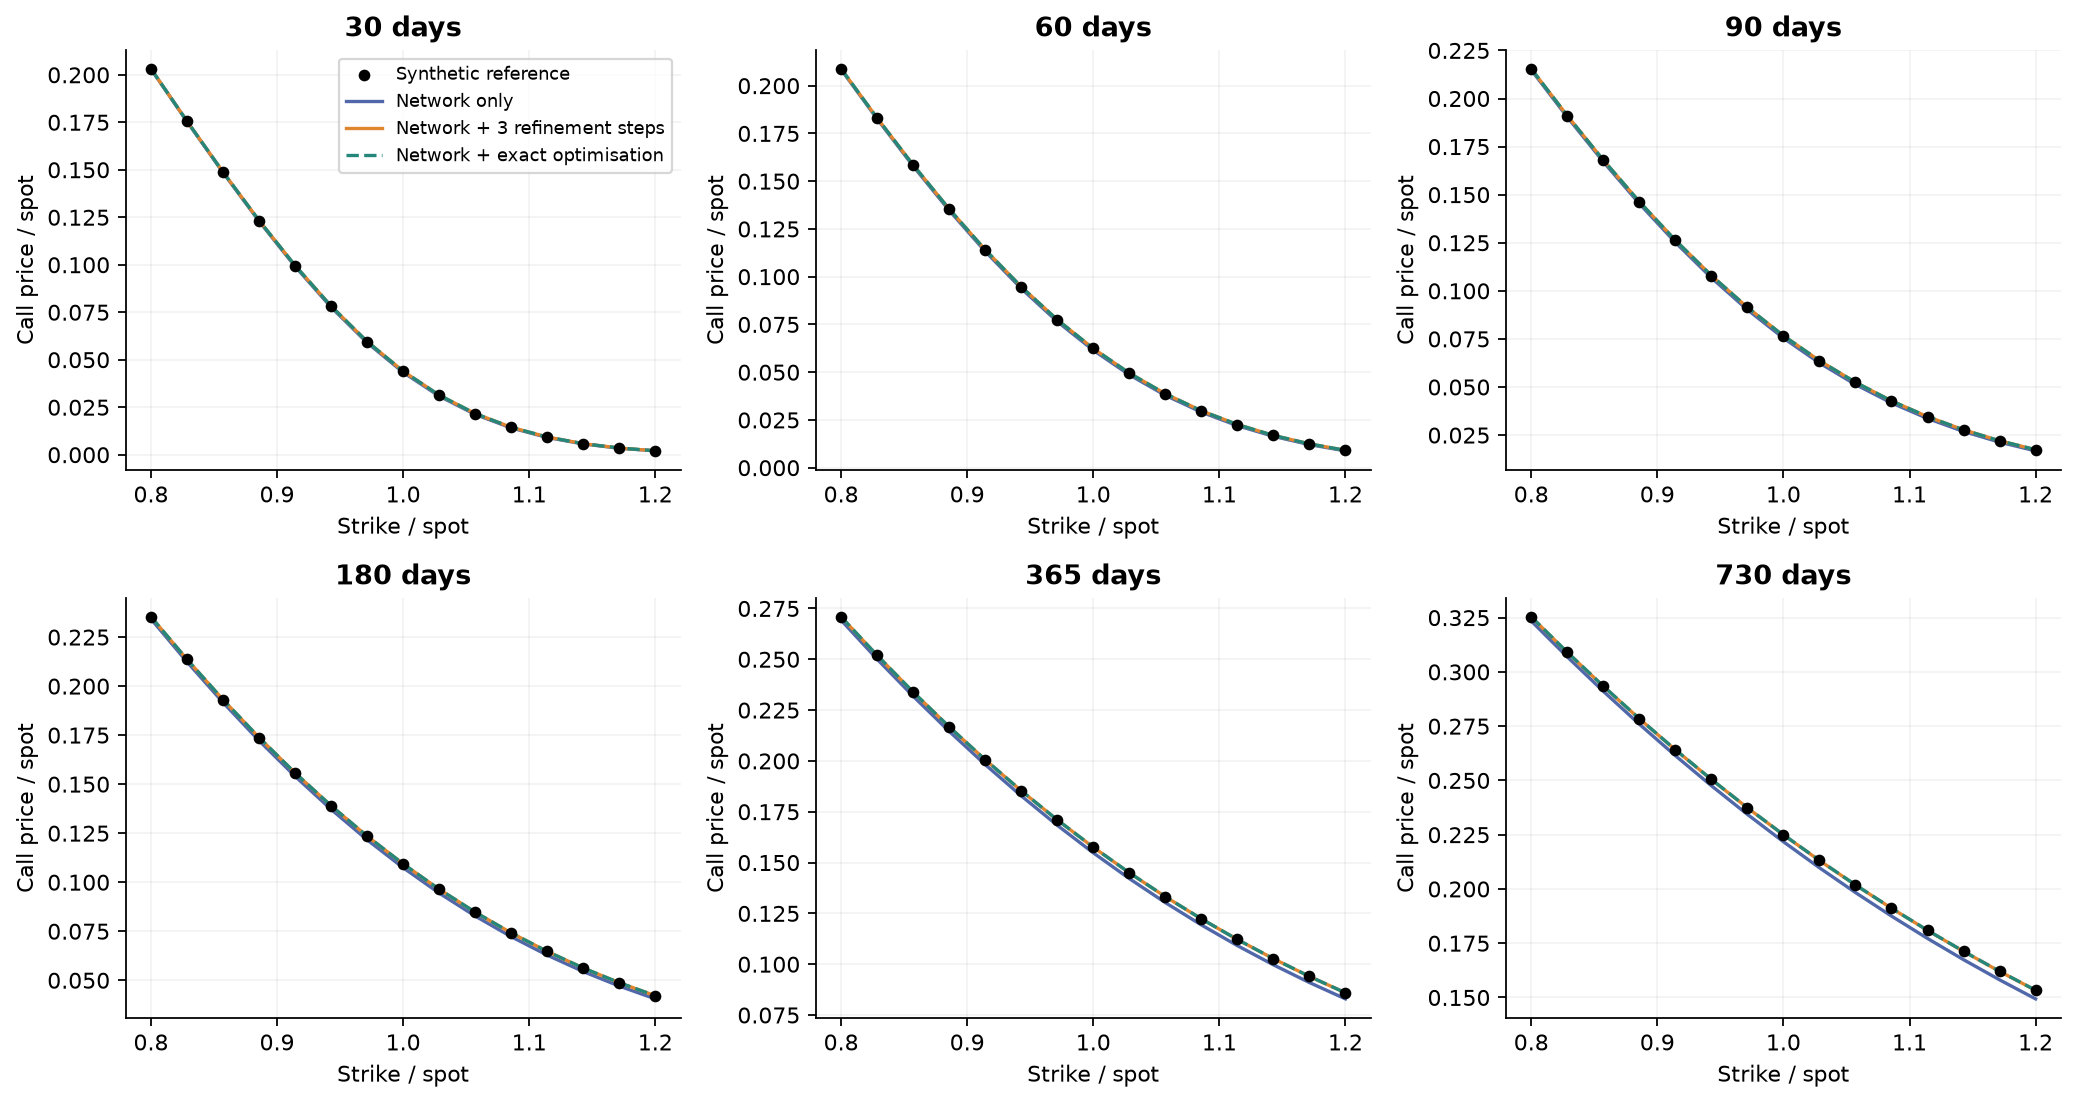

In [4]:
display(Image(filename=str(BASE / 'figures' / 'example_price_surface.png')))


The first prespecified synthetic case is shown across six maturities. Black points are exact-engine synthetic prices, not NSE observations. Lines use the estimated parameters. An overlapping line demonstrates price reconstruction for this case, not universal parameter identification.

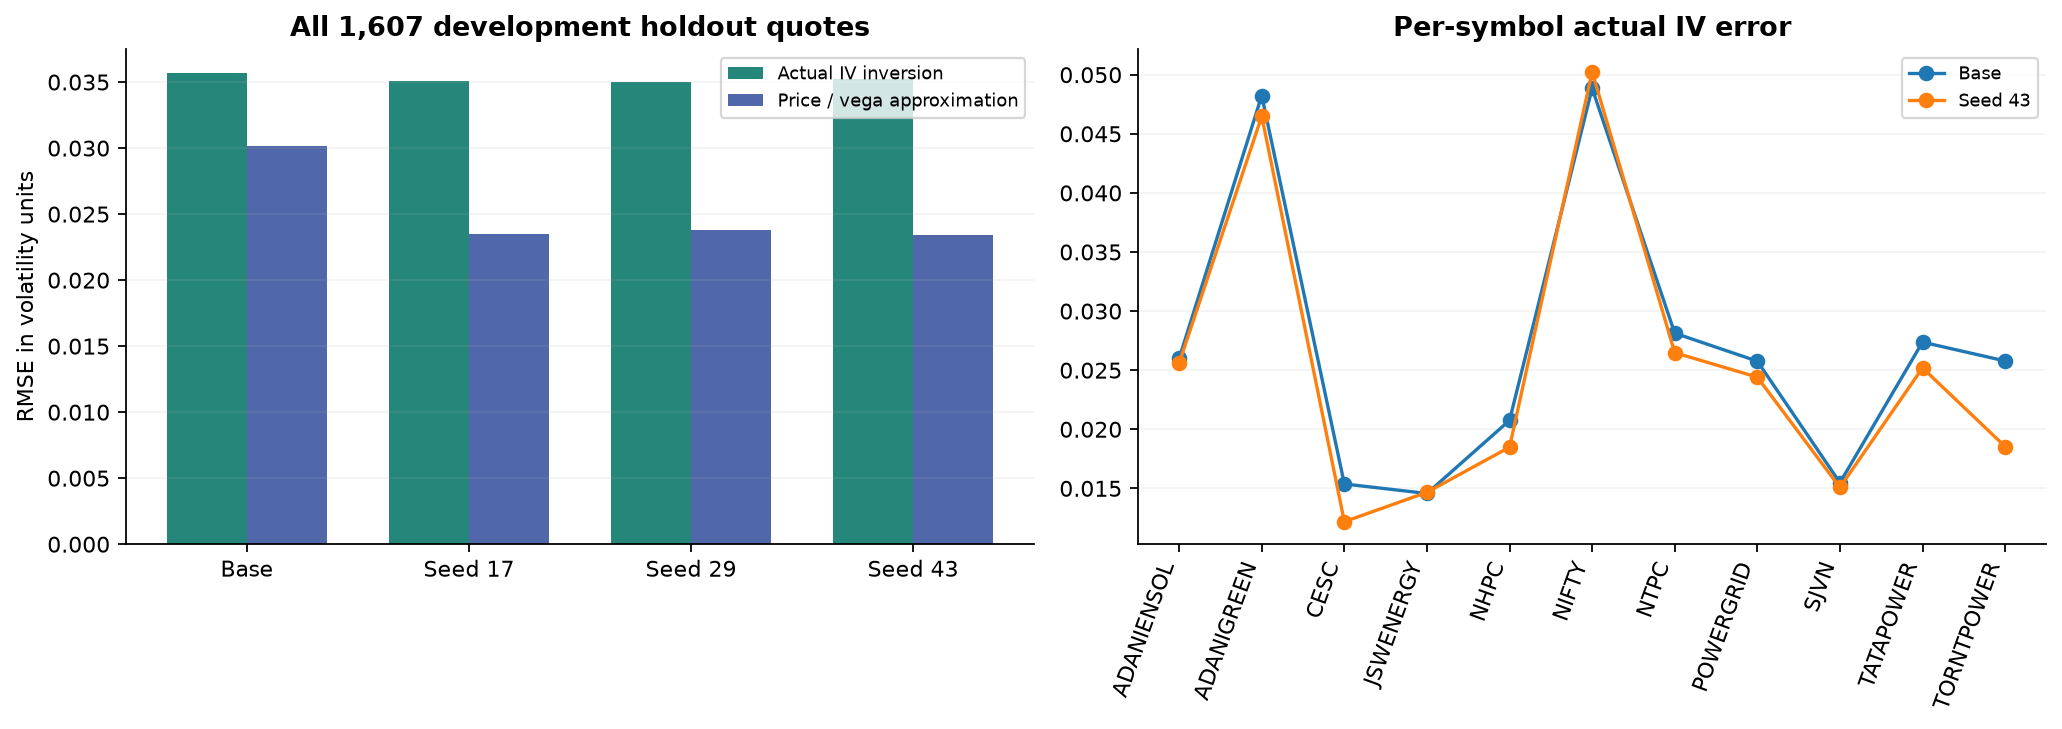

In [5]:
display(Image(filename=str(BASE / 'figures' / 'market_development_iv.png')))


These are development-validation results, including dates used for checkpoint selection. Actual IV error is recomputed by inversion, separately from the price/vega approximation. Seven near-zero model prices across all four models use independently checked high-precision inversion; none are clipped or dropped. The symbol breakdown exposes gains or regressions hidden by the pooled average; it is not a fresh market test.

In [6]:
parameters = pd.read_csv(BASE / 'all_parameter_recovery.csv')
display(parameters.query("model == 'seed_43/repaired' and geometry == 'rich' and noise == 0").head(30))
market_parameters = pd.read_csv(BASE / 'market_validation' / 'surface_parameters_and_metrics.csv')
display(market_parameters.head())


,case,geometry,noise,model,arm,parameter,true,estimated,absolute_error
60,905101_00,rich,0.0,seed_43/repaired,encoder,kappa_slow,0.451571,0.457317,5.745428e-03
61,905101_00,rich,0.0,seed_43/repaired,encoder,theta_slow,0.031871,0.056667,2.479565e-02
62,905101_00,rich,0.0,seed_43/repaired,encoder,sigma_slow,0.036661,0.110051,7.339045e-02
63,905101_00,rich,0.0,seed_43/repaired,encoder,rho_slow,-0.390588,-0.371491,1.909616e-02
64,905101_00,rich,0.0,seed_43/repaired,encoder,v0_slow,0.052095,0.066780,1.468557e-02
65,905101_00,rich,0.0,seed_43/repaired,encoder,kappa_fast,8.066471,6.921040,1.145431e+00
66,905101_00,rich,0.0,seed_43/repaired,encoder,theta_fast,0.078126,0.055892,2.223399e-02
67,905101_00,rich,0.0,seed_43/repaired,encoder,sigma_fast,0.419563,0.442933,2.337058e-02
68,905101_00,rich,0.0,seed_43/repaired,encoder,rho_fast,-0.223261,-0.043580,1.796810e-01
69,905101_00,rich,0.0,seed_43/repaired,encoder,v0_fast,0.089386,0.071358,1.802863e-02


,model,checkpoint_seed,surface_index,label,symbol,trade_date,fit_quotes,holdout_quotes,fit_expiries,iv_rmse_all_quotes,...,rho_slow,v0_slow,kappa_fast,theta_fast,sigma_fast,rho_fast,v0_fast,fit_penalized_objective,batch_amortized_calibration_and_pricing_seconds,inference_error
0,unified_v6/unified (seed not_recorded),not_recorded,0,ADANIENSOL|2026-02-02,ADANIENSOL,2026-02-02,11,6,1,0.028706,...,-0.365572,0.040468,26.086718,0.142152,2.178095,-0.074854,0.129255,354.046029,0.040124,NaN
1,unified_v6/unified (seed not_recorded),not_recorded,1,ADANIENSOL|2026-02-03,ADANIENSOL,2026-02-03,15,7,1,0.035475,...,-0.310083,0.017612,14.603830,0.207738,2.266020,-0.025919,0.138145,740.893626,0.040124,NaN
2,unified_v6/unified (seed not_recorded),not_recorded,2,ADANIENSOL|2026-02-04,ADANIENSOL,2026-02-04,13,6,1,0.025311,...,-0.328656,0.025447,30.893073,0.160022,2.710480,-0.042272,0.127741,1415.411534,0.040124,NaN
3,unified_v6/unified (seed not_recorded),not_recorded,3,ADANIENSOL|2026-02-05,ADANIENSOL,2026-02-05,13,6,1,0.021973,...,-0.382636,0.034755,34.311024,0.137822,2.653660,-0.158224,0.101890,567.234092,0.040124,NaN
4,unified_v6/unified (seed not_recorded),not_recorded,4,ADANIENSOL|2026-02-06,ADANIENSOL,2026-02-06,17,8,1,0.033236,...,-0.284368,0.019020,18.963451,0.158428,2.161481,-0.325536,0.106578,64.128045,0.040124,NaN


The first table has synthetic generating labels; the market parameter table contains fitted estimates only. They must not be presented as observed true market parameters.